<a id="08"></a>

## 08 — Summary & Research Questions
### Mục 0.4 — Hình thành giả thuyết nghiên cứu & Tổng kết Giai đoạn 0

**Mục đích**: tổng hợp kết quả từ 7 notebook trước, xác nhận Giai đoạn 0
đã hoàn chỉnh, và trình bày lại 5 câu hỏi nghiên cứu (RQ1–RQ5) cùng giả
thuyết tương ứng (H1–H5) — cầu nối chuyển sang thiết kế pipeline chính
thức ở Giai đoạn 1–4.

Notebook này **không tạo phân tích mới** — chỉ tổng hợp lại output đã lưu
từ các notebook 01–07. Nếu có ô báo lỗi "không tìm thấy file", quay lại
chạy notebook tương ứng trước.

## 1. Tổng quan manifest

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from typing import Any
from matplotlib.patches import Rectangle

from common import io_utils, pipeline, synthetic, dsp, features, splitting, config as cfg

pd.set_option("display.max_colwidth", 120)

In [2]:
USE_SYNTHETIC_DATA = False
REAL_DATA_ROOT = Path("../../data/raw")            # <-- data/raw/
SYNTHETIC_DATA_ROOT = Path("./_data/synthetic_cwru")
OUTPUT_DIR = Path("./outputs")
FORCE_REBUILD_MANIFEST = False  # manifest đã được build ở notebook 01
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

In [3]:
manifest = pipeline.get_manifest(
    use_synthetic=USE_SYNTHETIC_DATA,
    real_data_root=REAL_DATA_ROOT,
    synthetic_data_root=SYNTHETIC_DATA_ROOT,
    output_dir=OUTPUT_DIR,
    force_rebuild=False,   # dùng lại manifest đã build ở notebook 01
)

n_total = len(manifest)
n_warn = int(manifest["has_warning"].sum())
print(f"Tổng số file trong manifest : {n_total}")
print(f"Số file có cảnh báo         : {n_warn} ({n_warn/max(n_total,1)*100:.1f}%)")

print("\nSố file theo (nhãn x tải):")
print(manifest.pivot_table(index="label", columns="load_hp", values="file_path", aggfunc="count", fill_value=0))

Tổng số file trong manifest : 161
Số file có cảnh báo         : 125 (77.6%)

Số file theo (nhãn x tải):
load_hp   0   1   2   3
label                  
B        10  10  10  10
IR       10  10  10  10
Normal    1   1   1   1
OR       20  19  19  19


In [4]:
# Đếm số lần xuất hiện theo LOẠI cảnh báo (parse từ cột warnings)
warning_keywords = [
    "NGHI_NGO_SAMPLING_RATE", "THOI_LUONG_BAT_THUONG", "RPM_LECH",
    "VONG_BI_NTN", "DUONG_KINH_LA", "OR_THIEU_VI_TRI", "OR_NGOAI_PHAM_VI",
    "THIEU_NHAN", "THIEU_TAI",
]
all_warnings_text = " ".join(manifest["warnings"].fillna("").tolist())
counts = {kw: all_warnings_text.count(kw) for kw in warning_keywords}
counts_df = pd.Series(counts, name="so_lan_xuat_hien").sort_values(ascending=False)
counts_df.to_csv(TABLES_DIR / "08_warning_counts_summary.csv")
counts_df[counts_df > 0]

OR_NGOAI_PHAM_VI          47
NGHI_NGO_SAMPLING_RATE    16
VONG_BI_NTN                8
RPM_LECH                   1
THOI_LUONG_BAT_THUONG      1
Name: so_lan_xuat_hien, dtype: int64

## 2. Các hình minh chứng đã tạo (notebook 02–05, 07)

--- So sánh dạng sóng thời gian (notebook 02) ---


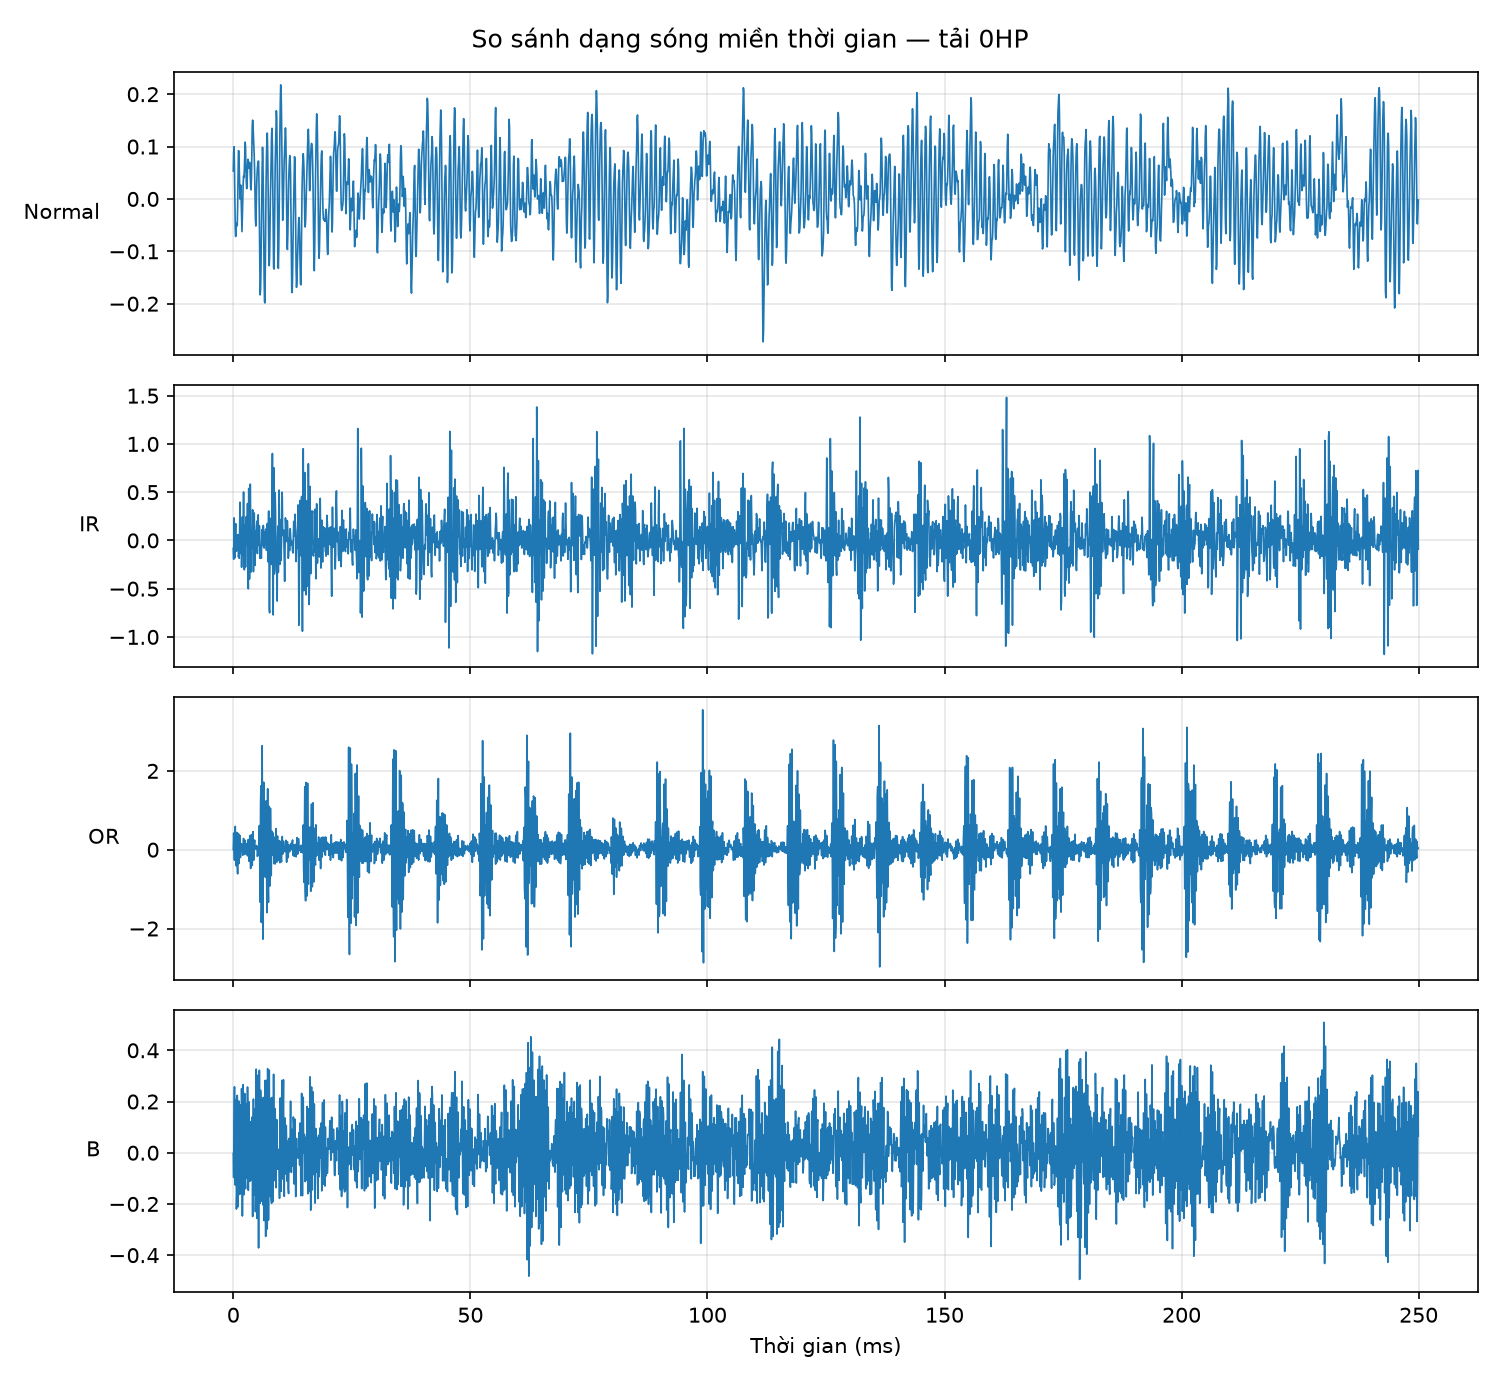


--- FFT trục Hz qua các tải (notebook 03) ---


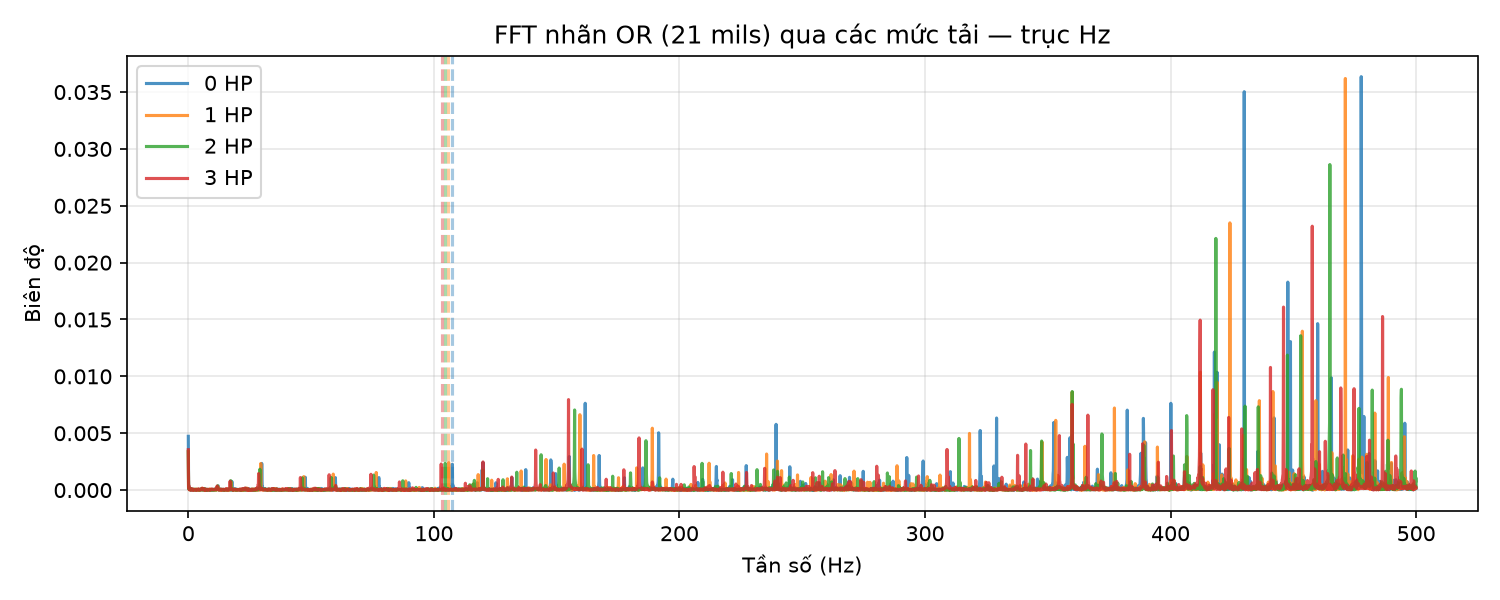


--- Phổ Order qua các tải (notebook 04) ---
  [chưa có — chạy notebook tương ứng trước] outputs\figures\04_order_domain_across_loads.png

--- Phổ Envelope Square-Law (notebook 05) ---


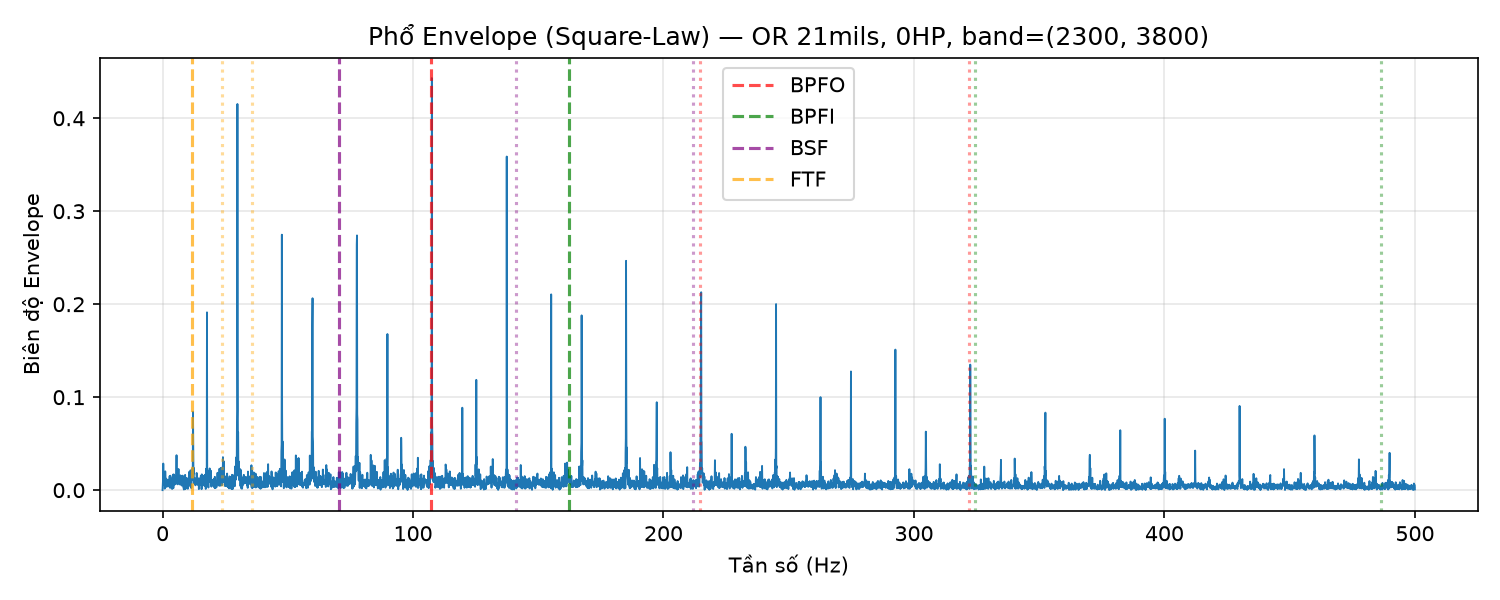


--- Cấu trúc 4-fold LOLO (notebook 07) ---


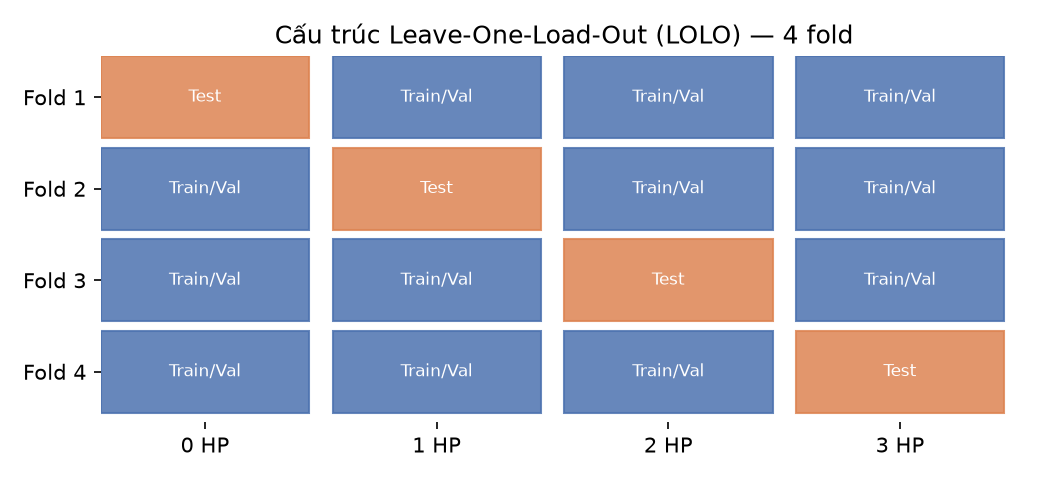

In [5]:
figure_files = [
    ("02_time_domain_comparison.png", "So sánh dạng sóng thời gian (notebook 02)"),
    ("03_fft_hz_across_loads.png", "FFT trục Hz qua các tải (notebook 03)"),
    ("04_order_domain_across_loads.png", "Phổ Order qua các tải (notebook 04)"),
    ("05_envelope_spectrum_square_law.png", "Phổ Envelope Square-Law (notebook 05)"),
    ("07_lolo_structure.png", "Cấu trúc 4-fold LOLO (notebook 07)"),
]

for fname, caption in figure_files:
    fpath = FIGURES_DIR / fname
    print(f"--- {caption} ---")
    if fpath.exists():
        display(Image(filename=str(fpath)))
    else:
        print(f"  [chưa có — chạy notebook tương ứng trước] {fpath}")
    print()